---

# Flower Species Classification with Naïve Bayes

Naïve Bayes is a probabilistic classifier based on Bayes' theorem with the "naïve" assumption that all features are conditionally independent given the class label. Despite this simplification, it often performs surprisingly well in practice and is extremely fast to train.

Gaussian Naïve Bayes assumes that the features follow a normal distribution within each class. For each class, it estimates the mean and variance of each feature from the training data, then uses these to compute the likelihood of a new observation belonging to that class.

In this notebook, we apply Gaussian Naïve Bayes to the Iris dataset to classify flowers into three species based on their sepal and petal measurements.

---

In [8]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own GaussianNaiveBayes implementation from ml_pack
from ml_pack import GaussianNaiveBayes

# Sklearn tools for preprocessing and evaluation only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

---

## Loading and Exploring the Data

---

In [9]:
# Load the Iris dataset
df = pd.read_csv("iris.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---

## Defining Features and Target

---

In [10]:
# Separate features and target
X = df.drop(columns='species').values
y = df['species'].values

print("Feature matrix shape:", X.shape)
print("Classes:", np.unique(y))
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: {'setosa': np.int64(50), 'versicolor': np.int64(50), 'virginica': np.int64(50)}


---

## Splitting and Scaling the Data

---

In [11]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (120, 4)
Test set size: (30, 4)


---

## Training the Model

---

In [12]:
# Train our custom Gaussian Naive Bayes model
model = GaussianNaiveBayes()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['setosa', 'versicolor', 'virginica']))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



---

## Confusion Matrix

---

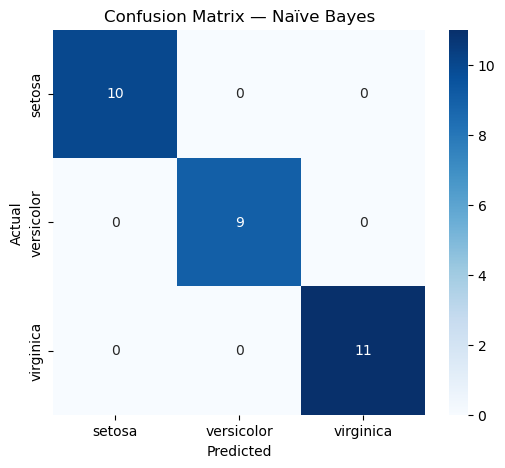

In [13]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Naïve Bayes")
plt.show()

---

## Visualizing Class Distributions

Naïve Bayes works by modeling the distribution of each feature within each class. Let's visualize how the features are distributed across the three species to understand why the model performs so well.

---

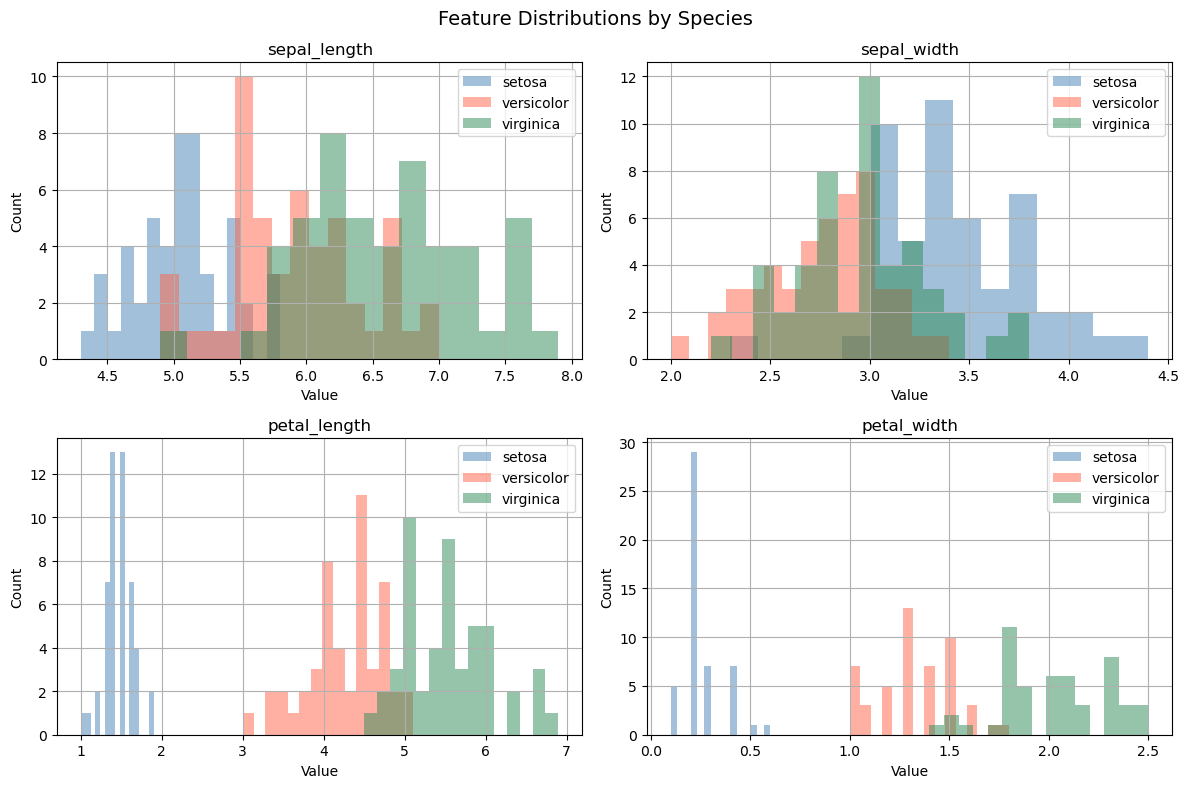

In [14]:
# Plot feature distributions per class
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = ['steelblue', 'tomato', 'seagreen']

for ax, feature in zip(axes.ravel(), features):
    for species, color in zip(df['species'].unique(), colors):
        subset = df[df['species'] == species][feature]
        ax.hist(subset, alpha=0.5, color=color, label=species, bins=15)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True)

plt.suptitle("Feature Distributions by Species", fontsize=14)
plt.tight_layout()
plt.show()

---

## Summary

In this notebook we applied Gaussian Naïve Bayes to classify iris flowers into three species based on sepal and petal measurements. The model achieved 100% accuracy on the test set.

Key takeaways:
- Naïve Bayes assumes features are conditionally independent given the class label
- Gaussian Naïve Bayes models each feature as a normal distribution within each class
- Despite the independence assumption being unrealistic, the model performs extremely well on the Iris dataset
- The feature distribution plots show clear separation between species, especially for petal length and petal width
- Naïve Bayes is fast, interpretable, and works well even with small datasets

---